In [3]:
!pip install qalsadi

In [4]:
import re
import pandas as pd
import numpy as np
import nltk
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import qalsadi.lemmatizer
from sklearn.metrics import confusion_matrix
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, classification_report
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
negation_words = {'لا', 'لم', 'لن', 'ليس', 'غير', 'ما', 'لاسيما', 'مش', 'مفيش', 'مافيش'}
egyptian_stopwords = {'ده', 'دي', 'دا', 'اللي', 'عشان', 'علشان', 'بقى', 'كده', 'يا', 'انو', 'يعني', 'اهو', 'هيك'}
arabic_stopwords = set(stopwords.words('arabic')) - negation_words
arabic_stopwords.update(egyptian_stopwords)
lemmer = qalsadi.lemmatizer.Lemmatizer()

In [7]:
df = pd.read_csv(r'C:\Users\lenovo\Documents\Projet_text_mining\Arabic_reviews\ar_reviews_100k.tsv', sep='\t')
df.dropna(inplace=True)
df.head()

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


In [9]:
lemma_cache = {}

def preprocess_arabic(text):
    if not isinstance(text, str): 
        return ""
    # "ممتاز" (2 fois) reste "ممتاز" | "جدااااا" (5 fois) devient "جدا"
    text = re.sub(r'(.)\1{2,}', r'\1', text) 
    
    text = re.sub(r"[\u064B-\u0652]", "", text) # Suppression voyelles (Tashkeel)
    # Normalisation
    text = re.sub("[إأآ]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)

    text = re.sub(r'[^\w\s]', ' ', text) # Ponctuation      
    text = re.sub(r'\d+', '', text) # Chiffres            
    words = text.split()
    cleaned = []
    
    for w in words:
        # On retire le "ال" au début si le mot est assez long (pour ne pas casser "الآن" par exemple)
        if w.startswith('ال') and len(w) > 4:
            w = w[2:]

        if w in negation_words:
            cleaned.append(w)
            continue
            
        if w not in lemma_cache:
            l = lemmer.lemmatize(w)
            # Normalisation du résultat du lemmatizer
            l = re.sub("[إأآ]", "ا", l)
            l = re.sub("ى", "ي", l)
            l = re.sub("ة", "ه", l)
            lemma_cache[w] = l
        
        lemma = lemma_cache[w]
        
        # Filtrage des stopwords et mots courts
        if lemma not in arabic_stopwords:
            # On garde les mots > 2 lettres OU les mots de négation importants (مش, لا)
            if len(lemma) > 2 or lemma in negation_words:
                cleaned.append(lemma)
    
    return " ".join(cleaned)

In [10]:
df['clean_text'] = df['text'].apply(preprocess_arabic)
df.head()

,label,text,clean_text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوع ما نظيف موقع تجهيز والشاطيء مطعم
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,حدا اسباب ناجح امارات شخص دوله يعشق تراب نحب ا...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادف قوه تنقل صخب شارع قاهر هدوء جبل شيش تعرف ...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خالص مبدي مسي ابهار فيل زرق ميقراش حسن حمد مار...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء لا يتجزا فندق متكامل خدمه مري...


In [12]:
if df['label'].dtype == object:
    label_mapping = {'Positive': 2, 'Mixed': 1, 'Negative': 0}
    df['target'] = df['label'].map(label_mapping)
else:
    df['target'] = df['label']
df.head(20)

,label,text,clean_text,target
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...,ممتاز نوع ما نظيف موقع تجهيز والشاطيء مطعم,2
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...,حدا اسباب ناجح امارات شخص دوله يعشق تراب نحب ا...,2
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...,هادف قوه تنقل صخب شارع قاهر هدوء جبل شيش تعرف ...,2
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...,خالص مبدي مسي ابهار فيل زرق ميقراش حسن حمد مار...,2
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...,ياسات جلوريا جزء لا يتجزا فندق متكامل خدمه مري...,2
5,Positive,أسلوب الكاتب رائع جدا و عميق جدا، قرأته عدة مر...,اسلوب كاتب رايع جدا عميق جدا قاري كنت طالب مرح...,2
6,Positive,استثنائي. الهدوء في الجناح مع مسبح. عدم وجود ع...,استثنايي هدوء جناح مسبح عدم اجيد عازل جيد غرف ...,2
7,Positive,الكتاب هو السيرة الذاتية للحداثة في المملكة بل...,كتاب سير ذاتي للحداثه مملك بلسان برز معاصر تحل...,2
8,Positive,من أجمل ما قرأت.. رواية تستحق القراءة فعلا..,جمل ما روايه استحق قارء علا,2
9,Positive,بشكل عام جيده .. . التجاوب جيد جدا من قبل موظف...,شكل عام جيد تجاوب جيد جدا موظف استقبال خادم تو...,2


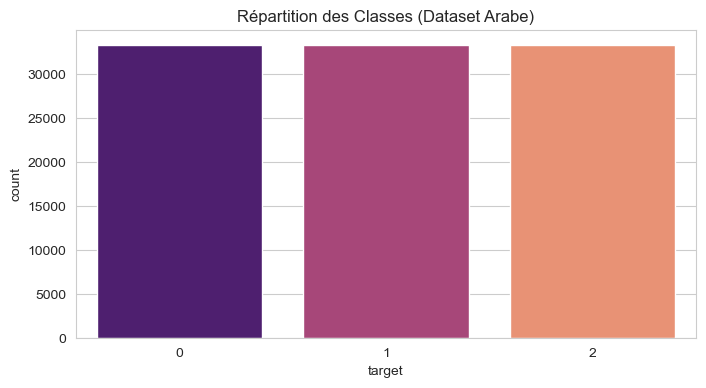

In [180]:
plt.figure(figsize=(8, 4))
sns.countplot(x='target', data=df, palette='magma', hue='label', legend=False)
plt.title('Répartition des Classes (Dataset Arabe)')
plt.show()

##### <font color = #D552A3>Analyse de la distribution :
On observe que les 3 classes sont parfaitement équilibrées.

In [17]:
X = df['clean_text']
y = df['target']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
print(f"Entraînement : {len(X_train)} abstracts")
print(f"Validation   : {len(X_test)} abstracts")

Entraînement : 79999 abstracts
Validation   : 20000 abstracts


In [136]:
print("\nSans feature selection")
baseline_data = []

# Ajout de la configuration (1, 2) pour les unigrammes + bigrammes
for name, ngram in [("Unigrammes", (1, 1)), ("Bigrammes", (2, 2)), ("Mixte", (1, 2))]:
    vec = TfidfVectorizer(ngram_range=ngram, max_features=20000)
    X_tr = vec.fit_transform(X_train)
    X_ts = vec.transform(X_test)
    
    model = LogisticRegression(max_iter=2000, C=1.0)
    model.fit(X_tr, y_train)
    acc = accuracy_score(y_test, model.predict(X_ts))
    
    baseline_data.append({'N-gramme': name, 'Accuracy': acc})

df_baseline = pd.DataFrame(baseline_data)
display(df_baseline)


Sans feature selection


,N-gramme,Accuracy
0,Unigrammes,0.6566
1,Bigrammes,0.6019
2,Mixte,0.6722


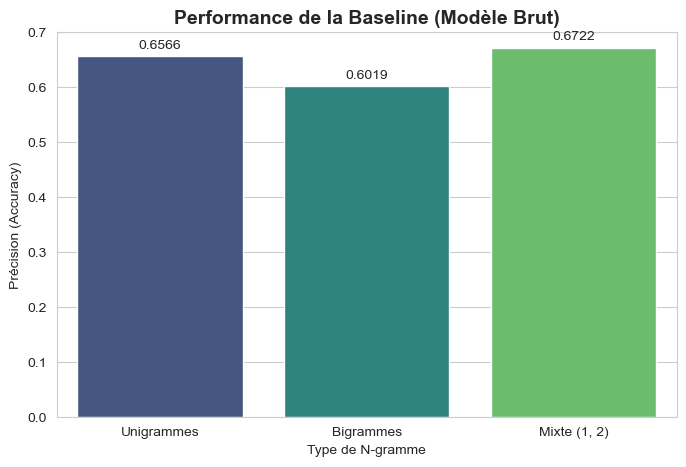

In [103]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# graphique
ax = sns.barplot(x='N-gramme', y='Accuracy', data=df_baseline, palette='viridis',    hue='N-gramme', legend=False)
plt.title('Performance de la Baseline (Modèle Brut)', fontsize=14, fontweight='bold')
plt.ylabel('Précision (Accuracy)')
plt.xlabel('Type de N-gramme')
plt.ylim(0, 0.7) 

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.show()

In [112]:
k_options = [1000, 2000, 5000, 10000, 20000] # Nombre de mots à garder
c_options = [0.1, 1.0, 10.0, 100]           # Force de la régularisation
# Ajout de l'option Mixte (1, 2) qui combine Unigrammes et Bigrammes
ngram_options = [
    ("Unigrammes", (1, 1)), 
    ("Bigrammes", (2, 2)), 
    ("Mixte", (1, 2))
]

results_grid = []

for ngram_name, ngram_range in ngram_options:
    print(f"Vectorisation en cours : {ngram_name}...")
    vec = TfidfVectorizer(ngram_range=ngram_range, max_features=20000)
    X_tr_raw = vec.fit_transform(X_train)
    X_ts_raw = vec.transform(X_test)
    
    for k in k_options:
        k_actual = min(k, X_tr_raw.shape[1])
        # Sélection des K meilleurs éléments avec Chi2
        selector = SelectKBest(chi2, k=k_actual)
        X_tr_k = selector.fit_transform(X_tr_raw, y_train)
        X_ts_k = selector.transform(X_ts_raw)
        
        for c in c_options:
            model = LogisticRegression(max_iter=2000, C=c)
            model.fit(X_tr_k, y_train)
            acc = accuracy_score(y_test, model.predict(X_ts_k))
            
            results_grid.append({
                'N-gramme': ngram_name,
                'K': k_actual,
                'C': c,
                'Accuracy': acc
            })

# Création du DataFrame de résultats
df_grid = pd.DataFrame(results_grid)

Vectorisation en cours : Unigrammes...
Vectorisation en cours : Bigrammes...
Vectorisation en cours : Mixte...


In [166]:
# --- 1. Matrice pour les Unigrammes ---
df_uni_opti = df_grid[df_grid['N-gramme'] == 'Unigrammes']
pivot_uni = df_uni_opti.pivot(index='K', columns='C', values='Accuracy')

print("="*50)
print("     Matrice d'optimisation : Unigrammes")
print("="*50)
display(pivot_uni)

# --- 2. Matrice pour les Bigrammes ---
df_bi_opti = df_grid[df_grid['N-gramme'] == 'Bigrammes']
pivot_bi = df_bi_opti.pivot(index='K', columns='C', values='Accuracy')

print("\n" + "="*50)
print("     Matrice d'optimisation : Bigrammes")
print("="*50)
display(pivot_bi)

# --- 3. Matrice pour le mode Mixte (Uni+Bi) ---
df_mixte_opti = df_grid[df_grid['N-gramme'] == 'Mixte']
pivot_mixte = df_mixte_opti.pivot(index='K', columns='C', values='Accuracy')

print("\n" + "="*50)
print("     Matrice d'optimisation : Mixte (Uni+Bi)")
print("="*50)
display(pivot_mixte)

     Matrice d'optimisation : Unigrammes


C,0.1,1.0,10.0,100.0
K,,,,
1000,0.64825,0.65230,0.65175,0.64985
2000,0.65310,0.65570,0.65290,0.65025
5000,0.65550,0.65855,0.65060,0.64140
10000,0.65735,0.65815,0.64400,0.62650
20000,0.65820,0.65660,0.63200,0.60405



     Matrice d'optimisation : Bigrammes


C,0.1,1.0,10.0,100.0
K,,,,
1000,0.56350,0.57125,0.57095,0.57090
2000,0.58090,0.58940,0.58980,0.58755
5000,0.59795,0.60165,0.59365,0.59085
10000,0.60430,0.60490,0.58985,0.57890
20000,0.60825,0.60190,0.57520,0.55060



     Matrice d'optimisation : Mixte (Uni+Bi)


C,0.1,1.0,10.0,100.0
K,,,,
1000,0.64125,0.65275,0.65165,0.64935
2000,0.65565,0.66495,0.66595,0.66305
5000,0.66660,0.67290,0.66630,0.65935
10000,0.66635,0.67505,0.65560,0.64215
20000,0.66695,0.67220,0.64255,0.61465


In [124]:
# On groupe par N-gramme pour trouver le meilleur de chaque catégorie
best_by_type = df_grid.loc[df_grid.groupby('N-gramme')['Accuracy'].idxmax()]

print("\n--- MEILLEURE COMBINAISON PAR TYPE DE N-GRAMME ---")
display(best_by_type.sort_values(by='Accuracy', ascending=False))


--- MEILLEURE COMBINAISON PAR TYPE DE N-GRAMME ---


,N-gramme,K,C,Accuracy
53,Mixte,10000,1.0,0.67505
9,Unigrammes,5000,1.0,0.65855
36,Bigrammes,20000,0.1,0.60825


In [138]:
df_grid['Feature Selection'] = df_grid['K'].apply(lambda x: f"AVEC (k={x})")

df_baseline_toplot = df_baseline.copy()
df_baseline_toplot['Feature Selection'] = 'SANS'
df_baseline_toplot['C'] = 1.0  
# On définit K à 20000 car c'est le max_features utilisé dans votre TfidfVectorizer baseline
df_baseline_toplot['K'] = 20000 

# Fusionner les résultats (Optimisation + Baseline)
df_plot_final = pd.concat([df_grid, df_baseline_toplot], ignore_index=True)

# On suit l'ordre croissant de K puis on termine par le modèle sans sélection
order = [f"AVEC (k={k})" for k in k_options] + ['SANS']

print("\n--- TOP 5 DES MEILLEURES CONFIGURATIONS (BASELINE INCLUSE) ---")
display(df_plot_final.sort_values(by='Accuracy', ascending=False).head(5))


--- TOP 5 DES MEILLEURES CONFIGURATIONS (BASELINE INCLUSE) ---


,N-gramme,K,C,Accuracy,Feature Selection
53,Mixte,10000,1.0,0.67505,AVEC (k=10000)
49,Mixte,5000,1.0,0.67290,AVEC (k=5000)
62,Mixte,20000,1.0,0.67220,SANS
57,Mixte,20000,1.0,0.67220,AVEC (k=20000)
56,Mixte,20000,0.1,0.66695,AVEC (k=20000)


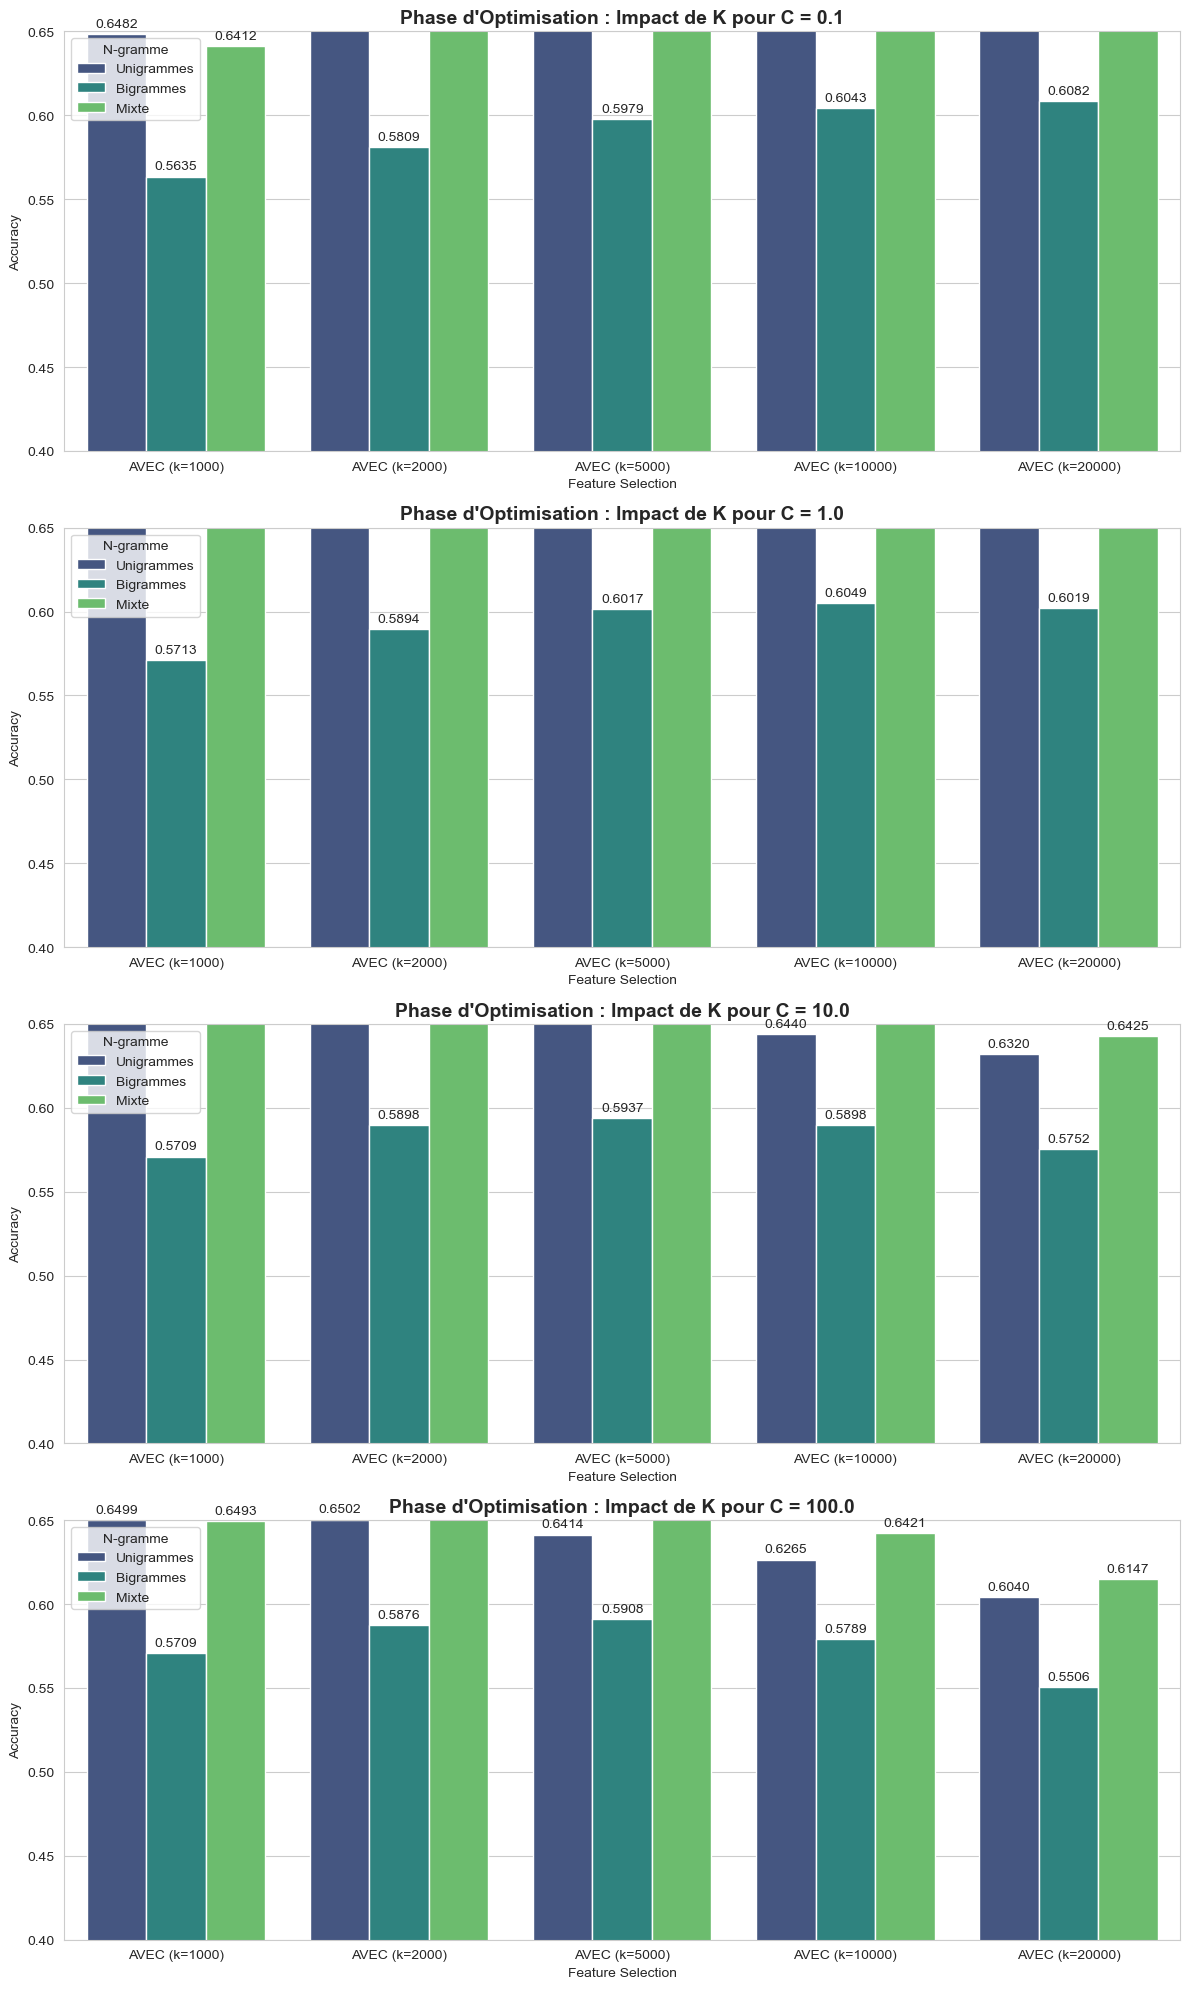

In [140]:
# 1. On filtre pour exclure le cas 'SANS' (on ne garde que la Grid Search)
df_optimization_only = df_plot_final[df_plot_final['Feature Selection'] != 'SANS']

# 2. On récupère les valeurs de C (0.1, 1.0, 10.0, etc.)
c_list = sorted(df_optimization_only['C'].unique())

# 3. Création des sous-graphiques (un par valeur de C)
fig, axes = plt.subplots(len(c_list), 1, figsize=(12, 5 * len(c_list)))

if len(c_list) == 1:
    axes = [axes]

for i, c_val in enumerate(c_list):
    # On isole les données pour cette valeur de C précise
    subset = df_optimization_only[df_optimization_only['C'] == c_val]
    
    ax = sns.barplot(
        x='Feature Selection', 
        y='Accuracy', 
        hue='N-gramme', 
        data=subset, 
        ax=axes[i],
        palette='viridis'
    )
    
    # Personnalisation
    axes[i].set_title(f'Phase d\'Optimisation : Impact de K pour C = {c_val}', fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.4, 0.65) 
    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

In [151]:
import re

# On trie par Accuracy descendante pour prendre le champion
best = df_plot_final.sort_values(by='Accuracy', ascending=False).iloc[0]

# Extraction des valeurs gagnantes
best_ngram_type = best['N-gramme']
best_c = best['C']
best_fs_label = best['Feature Selection']
best_k = int(best['K']) # On récupère K directement depuis la colonne numérique

print(f"Meilleure configuration : {best_ngram_type} | {best_fs_label} | C={best_c}")

# Reconstruction du pipeline gagnant avec gestion du mode Mixte
if "Mixte" in best_ngram_type:
    ngram_range = (1, 2)
elif "Bigrammes" in best_ngram_type:
    ngram_range = (2, 2)
else:
    ngram_range = (1, 1)

# Initialisation du vectoriseur final avec le bon range
v_final = TfidfVectorizer(ngram_range=ngram_range, max_features=20000)
X_tr_raw = v_final.fit_transform(X_train)
X_vl_raw = v_final.transform(X_test)

# Gestion de la Feature Selection (K)
if "AVEC" in best_fs_label:
    print(f"--- Application du filtre Chi2 avec k={best_k} ---")
    sel_f = SelectKBest(chi2, k=best_k)
    X_tr_f = sel_f.fit_transform(X_tr_raw, y_train)
    X_vl_f = sel_f.transform(X_vl_raw)
else:
    print("--- Utilisation du modèle complet (sans réduction K) ---")
    X_tr_f = X_tr_raw
    X_vl_f = X_vl_raw

# Entraînement du modèle final
final_model = LogisticRegression(C=best_c, max_iter=2000)
final_model.fit(X_tr_f, y_train)

# Prédiction et Rapport de performance
y_pred = final_model.predict(X_vl_f)

print("\n" + "="*40)
print("   RAPPORT DE CLASSIFICATION FINAL")
print("="*40)

# On définit les noms des classes pour le rapport
mapping_noms = {0: "Negative", 1: "Mixed", 2: "Positive"}
unique_labels = sorted(y_test.unique())
target_names = [mapping_noms[l] for l in unique_labels]

print(classification_report(y_test, y_pred, target_names=target_names))

Meilleure configuration : Mixte | AVEC (k=10000) | C=1.0
--- Application du filtre Chi2 avec k=10000 ---

   RAPPORT DE CLASSIFICATION FINAL
              precision    recall  f1-score   support

    Negative       0.71      0.74      0.73      6666
       Mixed       0.60      0.56      0.58      6667
    Positive       0.70      0.72      0.71      6667

    accuracy                           0.68     20000
   macro avg       0.67      0.68      0.67     20000
weighted avg       0.67      0.68      0.67     20000



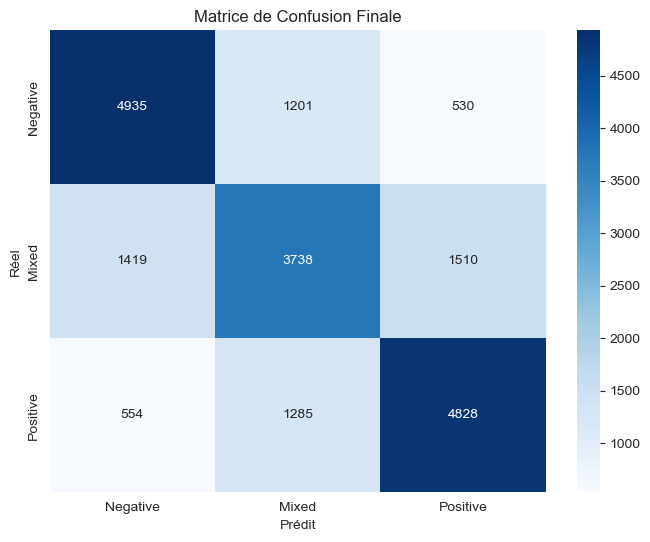

In [153]:
cm = confusion_matrix(y_test, y_pred)

#  Préparation de l'affichage
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice de Confusion Finale")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

In [164]:
print("--- RÉSULTATS DES TESTS MANUELS (SANS RÉ-ENTRAÎNEMENT) ---")

manual_test_data = [
    "الفندق ده ممتاز جدا والنظافة تحفة",                # Positive (2)
    "الاكل كان وحش اوي والخدمة زفت",                   # Negative (0)
    " المكان عادي يعني مش بطال بس مش واو ",             # Neutral/Mixed (1)
    "بصراحة تجربة زبالة وماصحش حد يروح هناك",           # Negative (0)
    "كل حاجة كانت تمام اوي شكرا ليكم",                 # Positive (2)
    "ممكن يكون احسن من كدة بكتير",                   # Neutral/Mixed (1)
    "مقبول بس مش قد التوقعات بصراحة",                # Neutral/Mixed (1)
    "عادي يعني لا حلو ولا وحش"                   # Neutral/Mixed (1)
                  
]

for text in manual_test_data:
    # 1. On nettoie la phrase
    cleaned = preprocess_arabic(text)
    
    # 2. On transforme la phrase avec le vectoriseur déjà existant (v_final)
    vec = v_final.transform([cleaned])
    
    # 3. On applique la sélection de caractéristiques existante (sel_f)
    # Note : On utilise sel_f directement
    vec_sel = sel_f.transform(vec)
    
    # 4. Prédiction avec le modèle déjà entraîné (final_model)
    pred = final_model.predict(vec_sel)[0]
    
    # Gestion des couleurs pour l'affichage
    if pred == 2: color = "\033[1;32m" # Vert
    elif pred == 0: color = "\033[1;31m" # Rouge
    else: color = "\033[1;34m" # Bleu
    
    print(f"Phrase : {text}")
    print(f"Nettoyé : {cleaned}") # Vérifiez ici si les mots importants restent !
    print(f"Prédiction : {color}{pred}\033[0m")
    print("-" * 30)

# On utilise X_vl_f qui est déjà votre X_test transformé et sélectionné
print("\n" + "="*60)
print("Réparitition des prédictions sur l'ensemble de test (X_test)")
print("="*60)

# Prédiction sur la matrice de validation déjà existante
y_test_preds = final_model.predict(X_vl_f)

temp_df = pd.DataFrame({'pred': y_test_preds})
stats = temp_df['pred'].value_counts(normalize=True).sort_index() * 100

mapping_noms = {0: "Negative", 1: "Mixed", 2: "Positive"}
for label, val in stats.items():
    nom = mapping_noms.get(label, label)
    print(f"Classe [{nom:<10}] : {val:>6.2f}% des données")

print("\n Tests terminés avec les objets actuels !")

--- RÉSULTATS DES TESTS MANUELS (SANS RÉ-ENTRAÎNEMENT) ---
Phrase : الفندق ده ممتاز جدا والنظافة تحفة
Nettoyé : فندق دهي ممتاز جدا والنظافه تحفه
Prédiction : 2
------------------------------
Phrase : الاكل كان وحش اوي والخدمة زفت
Nettoyé : كلي وحش اوي والخدمه زفت
Prédiction : 0
------------------------------
Phrase :  المكان عادي يعني مش بطال بس مش واو 
Nettoyé : مكان عني مش بطال مش
Prédiction : 0
------------------------------
Phrase : بصراحة تجربة زبالة وماصحش حد يروح هناك
Nettoyé : صراح جرب زبال وماصحش
Prédiction : 0
------------------------------
Phrase : كل حاجة كانت تمام اوي شكرا ليكم
Nettoyé : حاج كانت تامم اوي شكر وكم
Prédiction : 2
------------------------------
Phrase : ممكن يكون احسن من كدة بكتير
Nettoyé : ممكن كوي حسن دهي بكتير
Prédiction : 0
------------------------------
Phrase : مقبول بس مش قد التوقعات بصراحة
Nettoyé : مقبول مش توقع صراح
Prédiction : 1
------------------------------
Phrase : عادي يعني لا حلو ولا وحش
Nettoyé : عني لا حلو لا وحش
Prédiction : 1
------------